# MNIST Convolutional Neural Network with PyTorch

This complete workflow belongs to [Convolutional Neural Networks](../index.md). Keras and PyTorch use the same
seeded indices, normalization, architecture intent, training budget, metrics,
and diagnostic figures.

Set `HELIO_FAST_RUN=1` for a reduced one-epoch smoke run. In Colab select
**Runtime → Run all**; the canonical dataset is downloaded by the framework.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and reproducibility

In [3]:
import hashlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0


## Load data and create the shared split

In [4]:
FAST_RUN = os.getenv("HELIO_FAST_RUN", "0") == "1"
SEED = 42
EPOCHS = 1 if FAST_RUN else 5
BATCH_SIZE = 256

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


data_root = Path(
    os.getenv("HELIO_DATA_DIR", Path.home() / ".cache" / "helio-data-methods")
)
development_dataset = datasets.MNIST(data_root, train=True, download=True)
test_dataset = datasets.MNIST(data_root, train=False, download=True)
x_development = development_dataset.data.numpy()
y_development = development_dataset.targets.numpy()
x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=10000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

if FAST_RUN:
    train_indices = train_indices[:5000]
    validation_indices = validation_indices[:2000]
    x_test = x_test[:2000]
    y_test = y_test[:2000]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)
x_train = x_train[:, np.newaxis, ...]
x_validation = x_validation[:, np.newaxis, ...]
x_test = x_test[:, np.newaxis, ...]

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: 829d1431018b38bc
train=50,000, validation=10,000, test=10,000, epochs=5


## Inspect class coverage

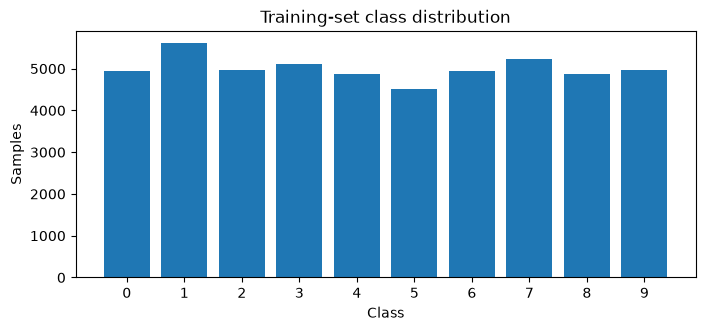

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Define the model

In [6]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 5 * 5, 200), nn.ReLU(),
            nn.Linear(200, 150), nn.ReLU(), nn.Dropout(0.5), nn.Linear(150, 10),
        )

    def forward(self, values):
        return self.classifier(self.features(values))


model = ImageClassifier()
print(model)

ImageClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=200, bias=True)
    (2): ReLU()
    (3): Linear(in_features=200, out_features=150, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=150, out_features=10, bias=True)
  )
)


## Train with validation evidence

epoch 1: loss=0.5572, accuracy=0.8216, val_loss=0.1168, val_accuracy=0.9658


epoch 2: loss=0.1252, accuracy=0.9631, val_loss=0.0731, val_accuracy=0.9775


epoch 3: loss=0.0830, accuracy=0.9760, val_loss=0.0564, val_accuracy=0.9837


epoch 4: loss=0.0659, accuracy=0.9803, val_loss=0.0546, val_accuracy=0.9843


epoch 5: loss=0.0528, accuracy=0.9846, val_loss=0.0430, val_accuracy=0.9880


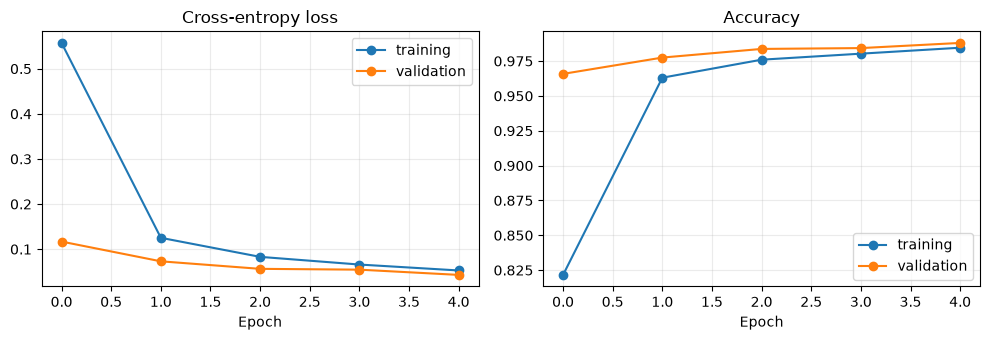

In [7]:
def tensor_dataset(images, labels):
    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels).long())


generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
validation_loader = DataLoader(
    tensor_dataset(x_validation, y_validation), batch_size=BATCH_SIZE
)
test_loader = DataLoader(tensor_dataset(x_test, y_test), batch_size=BATCH_SIZE)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
loss_function = nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}


def epoch_pass(loader, training):
    model.train(training)
    total_loss = 0.0
    correct = 0
    for features, target in loader:
        features, target = features.to(DEVICE), target.to(DEVICE)
        if training:
            optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, target)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(target)
        correct += (logits.argmax(1) == target).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


for epoch in range(EPOCHS):
    train_loss, train_accuracy = epoch_pass(train_loader, True)
    with torch.no_grad():
        validation_loss, validation_accuracy = epoch_pass(validation_loader, False)
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_accuracy"].append(validation_accuracy)
    print(
        f"epoch {epoch + 1}: loss={train_loss:.4f}, accuracy={train_accuracy:.4f}, "
        f"val_loss={validation_loss:.4f}, val_accuracy={validation_accuracy:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["loss"], marker="o", label="training")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history["accuracy"], marker="o", label="training")
axes[1].plot(history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluate once on the test set

test accuracy: 0.9900
              precision    recall  f1-score   support

           0      0.986     0.995     0.990       980
           1      0.991     1.000     0.996      1135
           2      0.991     0.995     0.993      1032
           3      0.990     0.991     0.991      1010
           4      0.989     0.996     0.992       982
           5      0.989     0.988     0.988       892
           6      0.995     0.991     0.993       958
           7      0.985     0.988     0.987      1028
           8      0.988     0.985     0.986       974
           9      0.996     0.970     0.983      1009

    accuracy                          0.990     10000
   macro avg      0.990     0.990     0.990     10000
weighted avg      0.990     0.990     0.990     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "829d1431018b38bc", "test_accuracy": 0.99}


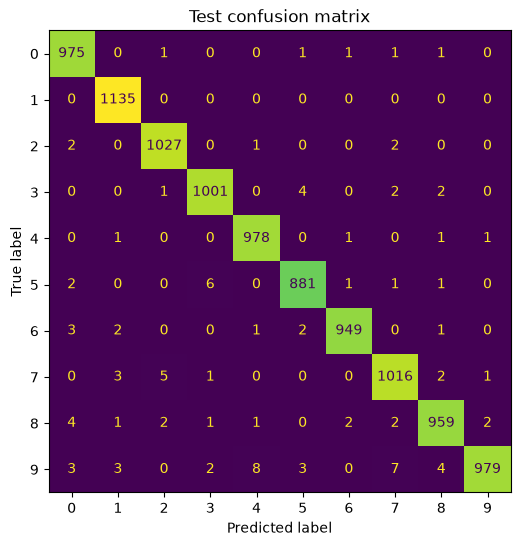

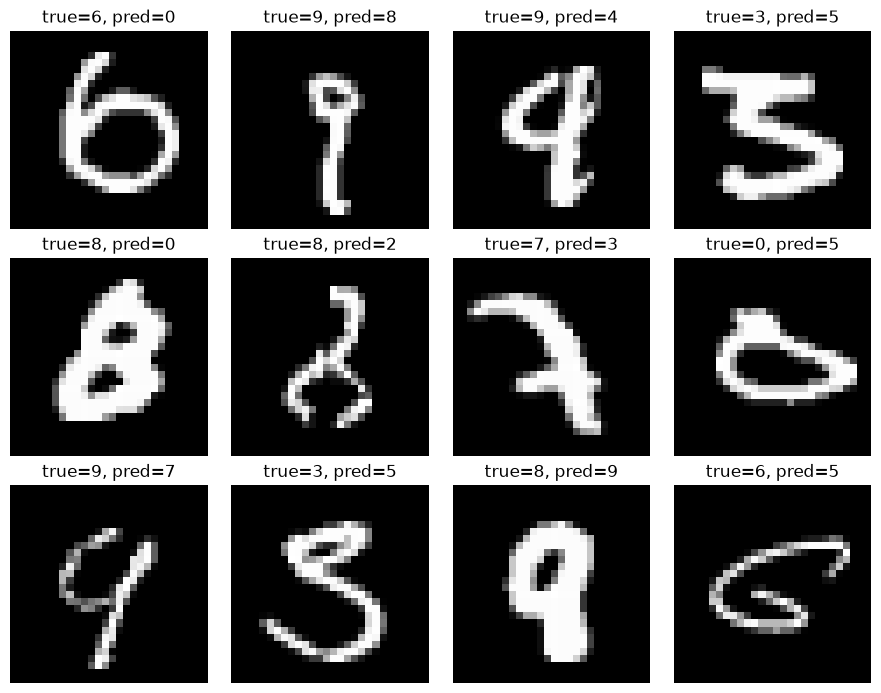

In [8]:
model.eval()
prediction_parts = []
with torch.no_grad():
    for features, _ in test_loader:
        prediction_parts.append(model(features.to(DEVICE)).argmax(1).cpu().numpy())
test_predictions = np.concatenate(prediction_parts)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- change the first convolution from 32 to 64 filters.
- compare 3×3 and 5×5 kernels.
- remove one pooling operation and inspect the tensor shapes.